# The Mandelbrot set

Renders the Mandelbrot set as a 1920×1080 PNG with a **transparent background**,
colored with this gradient:

```css
background: linear-gradient(90deg, #003f5b, #2b4b7d, #5f5195, #98509d, #cc4c91, #f25375, #ff6f4e, #ff9913);
```

The colors are not painted *onto* the set: they come out of the construction of the
set itself. Every point of the plane is colored by how fast its orbit escapes to
infinity — points that never escape (the set) get the first color, and the gradient
advances with the escape speed until, far from the set, the image fades to
transparent.

Only `numpy` and the standard library are needed — the PNG is written by hand.

In [1]:
import math
import struct
import zlib

import numpy as np

## Parameters

In [2]:
WIDTH, HEIGHT = 1920, 1080     # pixels of the final image
CENTER = complex(-0.765, 0.0)  # point of the complex plane at the center of the image
VIEW_HEIGHT = 2.4              # how much of the imaginary axis fits in the image
MAX_ITER = 1000                # iterations before we declare a point to be in the set
BAILOUT = 2.0**8               # |z| beyond which the orbit has certainly escaped
SUPERSAMPLE = 2                # render 2x2 samples per pixel, for antialiased edges

STOPS = ["#003f5b", "#2b4b7d", "#5f5195", "#98509d",
         "#cc4c91", "#f25375", "#ff6f4e", "#ff9913"]

GLOW_EDGE = 5.0   # points escaping in fewer iterations than this are transparent...
GLOW_FADE = 2.0   # ...with the opacity ramping up over this many iterations before it
GAMMA = 0.35      # <1 stretches the colors near the set, >1 pushes them outward

PNG_PATH = "mandelbrot.png"

## Escape time

The Mandelbrot set is the set of complex numbers *c* for which the sequence
*z*₀ = 0, *z*ₙ₊₁ = *z*ₙ² + *c* stays bounded. Once |*z*| > 2 the sequence is
guaranteed to escape to infinity, so `MAX_ITER` iterations without escaping is
our practical membership test.

But the iteration count at which a point escapes carries more information than
yes/no: it says how *close* the point is to the set. Points far away escape in two
or three iterations; points near the boundary take hundreds. That count is what
drives the colors.

The raw count is an integer, so it would color the plane in discrete bands. The
usual remedy — the *smooth* (or *continuous*) escape count — uses how far past the
bailout radius the orbit overshot on its last iteration to interpolate between
consecutive counts:

ν = *n* + 1 − log₂(log|*z*ₙ|)

`escape_time` computes ν for every sample point at once with numpy, dropping
escaped points from the working arrays as it goes. The two largest components of
the set — the main cardioid and the period-2 bulb — are detected with the usual
closed-form tests, which spares them the full iteration loop. Points in the set
get ν = ∞.

In [3]:
def escape_time(width, height, center, view_height, max_iter, bailout):
    """Smooth escape count of every sample point; inf for points in the set."""
    view_width = view_height * width / height
    xs = np.linspace(center.real - view_width / 2, center.real + view_width / 2, width)
    ys = np.linspace(center.imag + view_height / 2, center.imag - view_height / 2, height)
    nu = np.full(width * height, np.inf)

    rows_per_band = max(1, 2**22 // width)  # keep the temporary arrays a sane size
    for y0 in range(0, height, rows_per_band):
        y1 = min(y0 + rows_per_band, height)
        c = (xs[None, :] + 1j * ys[y0:y1, None]).ravel()

        # points known to be in the set: main cardioid and period-2 bulb
        x, y = c.real, c.imag
        q = (x - 0.25)**2 + y**2
        known = (q * (q + x - 0.25) <= 0.25 * y**2) | ((x + 1)**2 + y**2 <= 1 / 16)

        index = np.flatnonzero(~known) + y0 * width  # positions of the points to test
        c = c[~known]
        z = np.zeros_like(c)
        for n in range(1, max_iter + 1):
            z = z * z + c
            magnitude2 = z.real**2 + z.imag**2
            escaped = magnitude2 > bailout**2
            if escaped.any():
                nu[index[escaped]] = n + 1 - np.log2(np.log(np.sqrt(magnitude2[escaped])))
                index, z, c = index[~escaped], z[~escaped], c[~escaped]
                if index.size == 0:
                    break

    return nu.reshape(height, width)

## From escape time to color

Escape time grows *logarithmically* as a point approaches the set: each extra
iteration roughly halves the distance. To spread the gradient evenly over the space
around the set instead of piling it up against the boundary, the color is driven
by 2^−ν, which grows *linearly* with that distance. (Up to a constant, 2^−ν is the
*potential* of the set: the electrostatic potential the set would produce if it
were a charged conductor.)

- The potential is 0 on the set and 1 at `GLOW_EDGE` iterations; `GAMMA` bends it
  to balance the colors.
- The eight CSS stops are interpolated in sRGB, as a browser does, and the
  potential picks the color: first stop on the set, last stop where the glow
  fades out.
- Opacity is 0 for points that escape in fewer than `GLOW_EDGE − GLOW_FADE`
  iterations and 1 from `GLOW_EDGE` on — the background is whatever escapes fast.

In [4]:
def gradient(stops, samples=4096):
    """A (samples, 3) lookup table of RGB floats interpolating the CSS stops."""
    rgb = np.array([[int(s[i:i + 2], 16) / 255 for i in (1, 3, 5)] for s in stops])
    stop_positions = np.linspace(0.0, 1.0, len(stops))
    sample_positions = np.linspace(0.0, 1.0, samples)
    return np.stack([np.interp(sample_positions, stop_positions, rgb[:, channel])
                     for channel in range(3)], axis=1)


def smoothstep(x, lo, hi):
    """0 below lo, 1 above hi, a smooth S-curve in between."""
    u = np.clip((x - lo) / (hi - lo), 0.0, 1.0)
    return u * u * (3 - 2 * u)


def colorize(nu, stops, glow_edge, glow_fade, gamma):
    """Map escape times to premultiplied RGBA floats in [0, 1]."""
    potential = np.clip(2.0 ** (glow_edge - nu), 0.0, 1.0)  # 0 on the set, 1 at glow_edge
    lut = gradient(stops)
    rgb = lut[(potential**gamma * (len(lut) - 1)).astype(int)]
    alpha = smoothstep(nu, glow_edge - glow_fade, glow_edge)
    return np.concatenate([rgb * alpha[..., None], alpha[..., None]], axis=2)

## Writing an RGBA PNG

A PNG is a signature followed by tagged chunks; the pixels go in `IDAT` as
zlib-compressed scanlines, each prefixed with a filter byte (`0` = no filter).
Color type `6` means 8-bit RGBA, which is what carries the transparency.

In [5]:
def write_png(path, rgba):
    """Write a (height, width, 4) uint8 array as an RGBA PNG."""
    height, width, _ = rgba.shape
    scanlines = b"".join(b"\x00" + rgba[row].tobytes() for row in range(height))

    def chunk(tag, data):
        body = tag + data
        return struct.pack(">I", len(data)) + body + struct.pack(">I", zlib.crc32(body))

    with open(path, "wb") as png:
        png.write(b"\x89PNG\r\n\x1a\n")
        png.write(chunk(b"IHDR", struct.pack(">IIBBBBB", width, height, 8, 6, 0, 0, 0)))
        png.write(chunk(b"IDAT", zlib.compress(scanlines, 9)))
        png.write(chunk(b"IEND", b""))

## Render

The image is computed at `SUPERSAMPLE`× resolution and each block of samples is
averaged into one pixel, which antialiases the boundary. The averaging is done on
premultiplied color so that transparent samples don't bleed their color into their
neighbors; the result is un-premultiplied before it is written.

In [6]:
nu = escape_time(WIDTH * SUPERSAMPLE, HEIGHT * SUPERSAMPLE,
                 CENTER, VIEW_HEIGHT, MAX_ITER, BAILOUT)
samples = colorize(nu, STOPS, GLOW_EDGE, GLOW_FADE, GAMMA)

pixels = samples.reshape(HEIGHT, SUPERSAMPLE, WIDTH, SUPERSAMPLE, 4).mean(axis=(1, 3))
alpha = pixels[..., 3:]
rgb = pixels[..., :3] / np.where(alpha > 0, alpha, 1)  # un-premultiply
rgba = np.concatenate([rgb, alpha], axis=2)
write_png(PNG_PATH, (rgba.clip(0, 1) * 255 + 0.5).astype(np.uint8))

in_set = np.isinf(nu).mean()
print(f"{PNG_PATH}: {WIDTH}x{HEIGHT}; {in_set:.1%} of the samples are in the set, "
      f"{alpha.mean():.1%} of the image is (partly) opaque")

mandelbrot.png: 1920x1080; 14.7% of the samples are in the set, 49.0% of the image is (partly) opaque


## The result

Shown here against the notebook's background — every white pixel below is actually
transparent in the file.

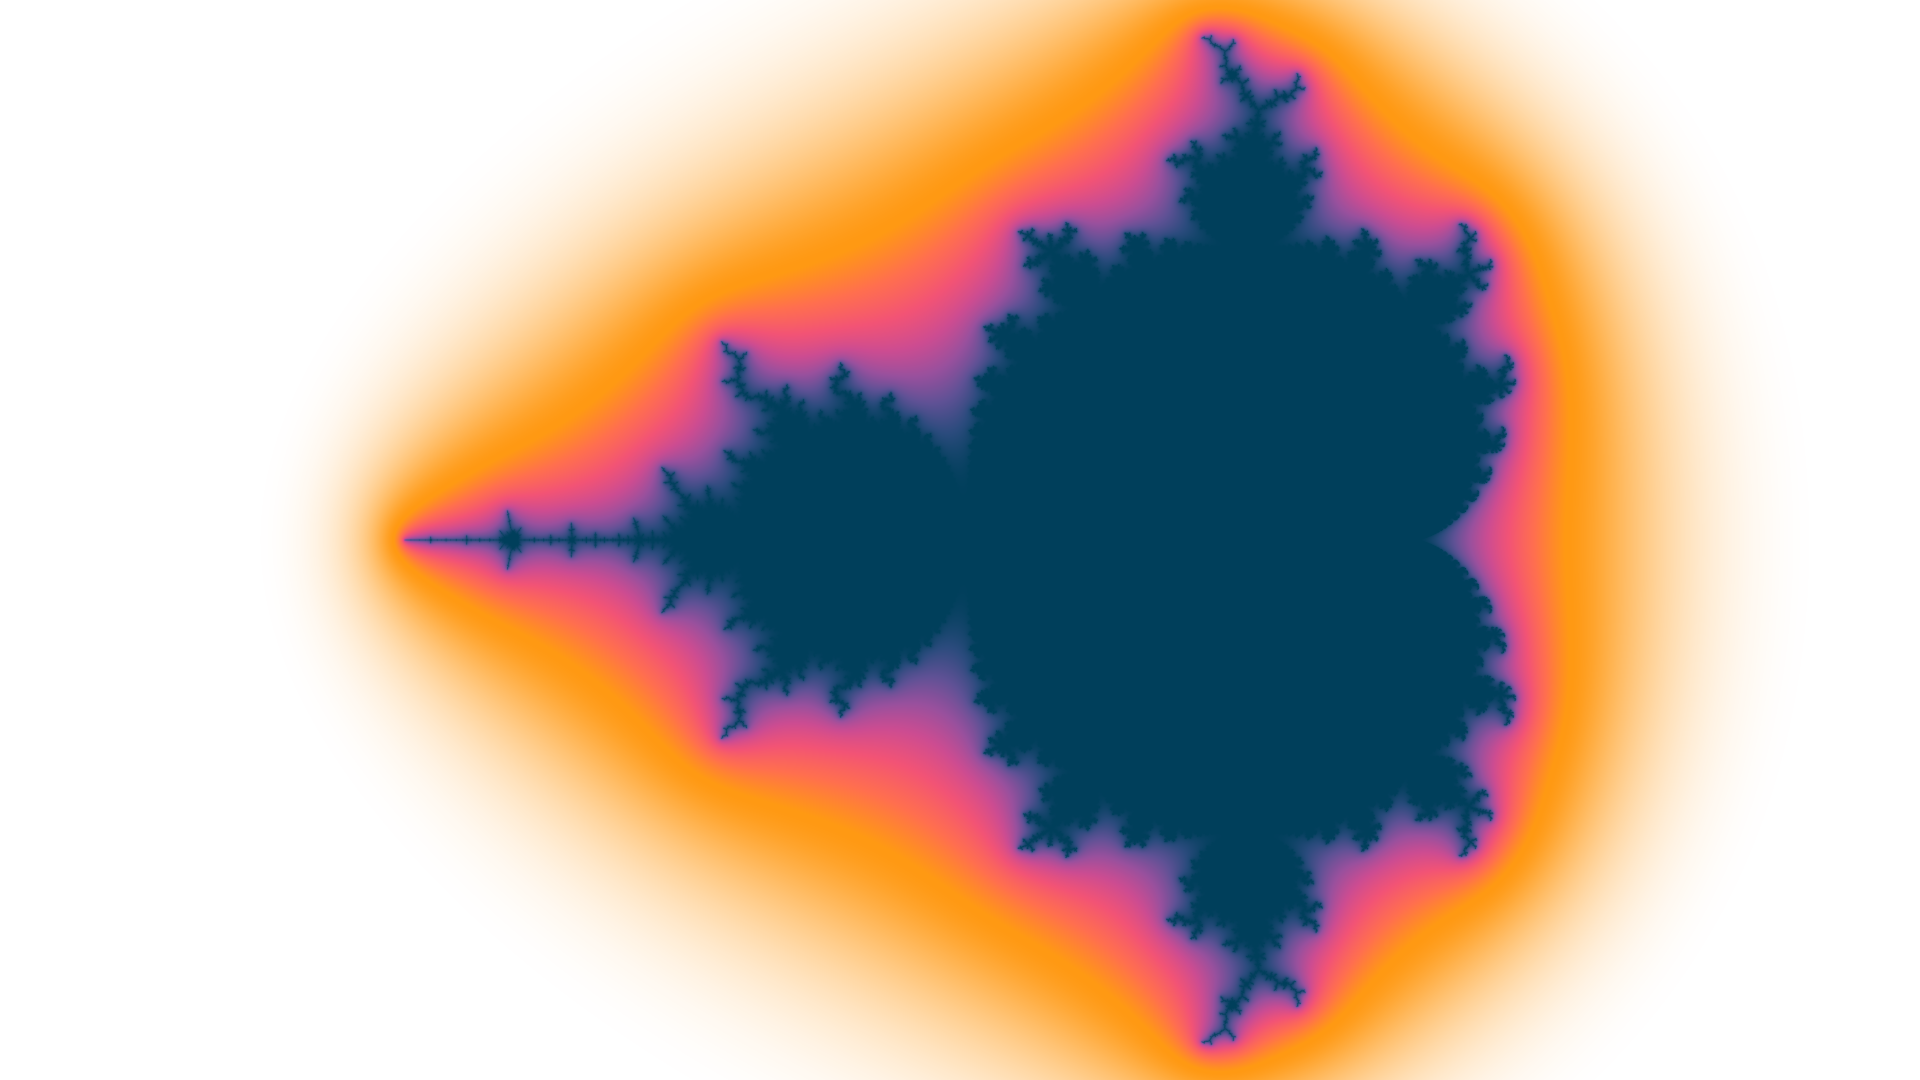

In [7]:
from IPython.display import Image

Image(PNG_PATH)